# Proposed approach:
- Compute hit rate from IAGOS data by aggregating IAGOS measurements onto the forecast grid. Forecast grid cells are flagged if at least one IAGOS measurement indicates that the grid cell contains a PCR. The hit rate is defined as the fraction of flagged grid cells where the forecast predicts persistent contrail formation.
- Penalize the forecast for overprediction by computing the total flight distance through forecast PCRs. This is computed by aggregating flight distance from a (hopefully) comprehensive ADSB dataset within forecast grid cells and summing aggregated flight distances over all grid cells where the forecast predicts persistent contrail formation.

Some implementation details:
- This approach requires defining boundaries for forecast grid cells. Our forecast has 0.25 degree horizontal resolution, 1 flight level vertical resolution, and hourly time resolution, so I'm defining points as points within +/- 0.125 degree, +/- 500 ft, and +/- 30 minutes from points where our forecast provides predictons.
- Aggregated IAGOS and ADSB data is very sparse at the granularity of our forecast (1 flight level and one time), so I'm trying to minimize processed data volume by saving results in parquet values with zeros dropped. The volume even of raw IAGOS data is tiny, so I don't anticipate any issues pulling aggregated IAGOS data to disk. Aggregated ADSB data requires about ~500 MB per flight level and time, though, which is probably too much to ask users to pull without some additional processing.
- I've so far just done an end-to-end demo evaluating an unbuffered forecast at a single level and time, but the aggregated ADSB and IAGOS data can be used to compute unbuffered metrics, too.

In [56]:
import datetime
import json
import os
import warnings

import aiohttp
import cartopy.crs as ccrs
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import binned_statistic_2d

from pycontrails.core import Fleet, JetA
from pycontrails.models import sac
from pycontrails.physics import constants, units
from pycontrails.utils import temp

In [33]:
time = datetime.datetime(2024, 6, 1, 10)
flight_level = 350

In [3]:
with open(os.path.expanduser("~/.contrailsapirc")) as f:
    keys = json.load(f)

# Contrails.org forecasts

I'm pulling EF values from the API and flagging grid cells where EF is nonzero (not necessarily positive) as predicted PCRs. This is all something an external user could reproduce, provided they have access to our API.

In [111]:
async def get_forecast(time: datetime.datetime, flight_level: int, key: str, sink: str) -> str:
    """Get forecast at a single level and time.

    Parameters
    ----------
    time : datetime.datetime
        Target time

    flight_level : int
        Target flight level

    key : str
        Contrails API key

    sink : str
        Path where forecast netcdf file should be saved
    
    """
    url = "https://api.contrails.org/v1/grids"
    params = {
        "aircraft_class": "default",
        "flight_level": flight_level,
        "time": time.strftime("%Y-%m-%dT%H"),
        "units": "ef_per_m"
    }
    headers = {"x-api-key": key}
    
    async with aiohttp.ClientSession(raise_for_status=True) as session:
        async with session.get(url, params=params, headers=headers) as resp:
            content = await resp.read()
            with open(sink, "wb") as f:
                f.write(content)

In [114]:
async def process_forecast(time: datetime.datetime, flight_level: int, key: str) -> str:
    """Process forecast at a single level and time.

    Parameters
    ----------
    time : datetime.datetime
        Target time

    flight_level : int
        Target flight level

    key : str
        Contrails API key

    Returns
    -------
    str
        Path to saved forecast netcdf file
    
    """
    with temp.temp_file() as raw:
        await get_forecast(time, flight_level, key, raw)
        ds = xr.open_dataset(raw, engine="netcdf4", decode_timedelta=True)
        pcr = ds["ef_per_m"] != 0
        pcr.attrs = {"long_name": "Persistent contrail region flag", "units": "1"}
        ds["pcr"] = pcr
        sink = f"{int(time.timestamp())}_{flight_level}.forecast.nc"
        ds[["pcr"]].to_netcdf(sink)
        return sink

In [115]:
sink = await process_forecast(time, flight_level, keys["prod"])
forecast = xr.open_dataset(sink)

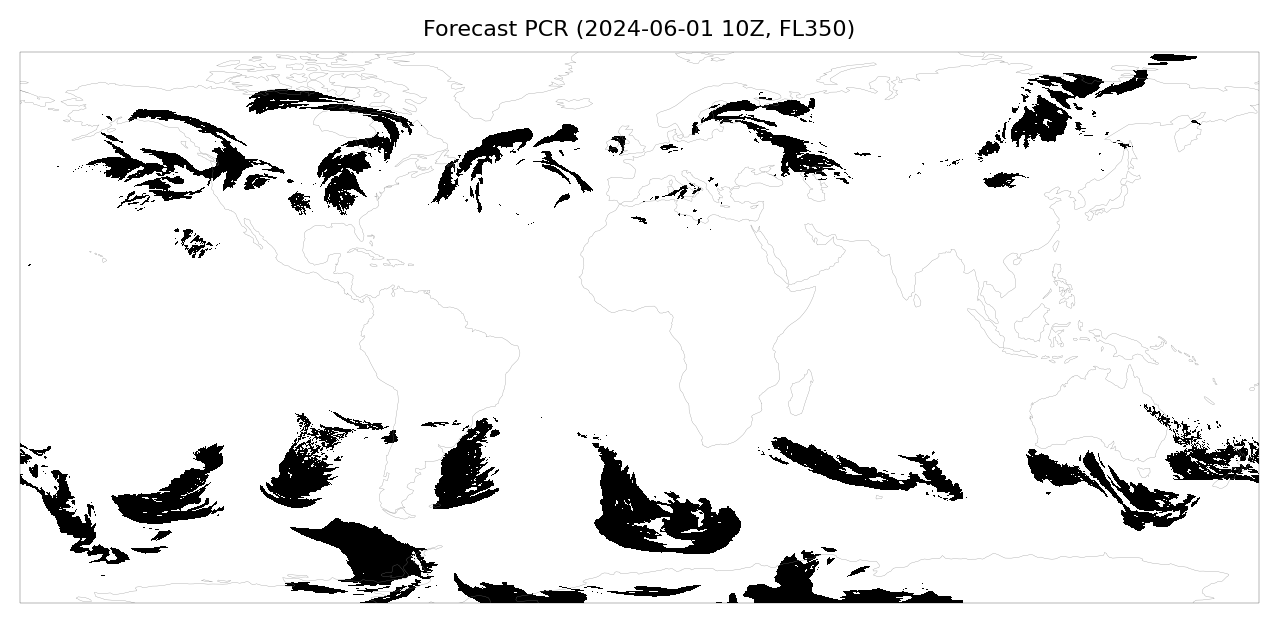

In [116]:
plt.figure(figsize=(6.5, 3), dpi=200, constrained_layout=True)
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.pcolormesh(forecast["longitude"], forecast["latitude"], forecast["pcr"].squeeze().T, cmap="Greys", shading="nearest")
ax.coastlines(color="gray", lw=0.1)
plt.setp(ax.spines.values(), linewidth=0.1)
ax.set_title(f"Forecast PCR ({time.strftime('%Y-%m-%d %HZ')}, FL{flight_level})", fontsize=8)
ax.set_extent([-180, 180, -80, 80]);

# ADSB data

I wanted to use our ADSB API for this step, but it doesn't cover the time period (mid-2024) that we're planning to use initially. I'm using Roger's merged Spire/Aireon data instead--we should consider whether this is the right data source, given that we're restricted on how we can share it.

In [8]:
def get_adsb(time: datetime.datetime, flight_level: int) -> pd.DataFrame:
    """Get one hour of global ADSB data centered at target time and flight level.

    Parameters
    ----------
    time : datetime.datetime
        Target time

    flight_level : int
        Target flight level

    Returns
    -------
    pd.DataFrame
        Unprocessed ADSB data

    """
    target = pd.Timestamp(time)
    start = target - pd.Timedelta(minutes=30)
    end = target + pd.Timedelta(minutes=30)

    gcs_path = "gs://contrails-301217-gaia/2024-Spire-Aireon/enhanced/accept/waypoints/{}-waypoints.pq"
    df = pd.read_parquet(gcs_path.format(start.floor("1d").strftime("%Y-%m-%d")))
    if end.floor("1d") != start.floor("1d"):
        df = pd.concat([df, pd.read_parquet(gcs_path.format(end.floor("1d").strftime("%Y-%m-%d")))], axis="index")

    df = df.sort_values(by=["flight_id", "timestamp"])

    # expand mask by 1 waypoint for segment length calculation
    low = flight_level * 100 - 500
    high = flight_level * 100 + 500
    mask = (df["timestamp"].between(start, end) & df["altitude_baro"].between(low, high)).values
    mask[1:] |= mask[:-1]
    mask[:-1] |= mask[1:]
    df = df[mask]

    return df

In [66]:
def process_adsb(time: datetime.datetime, flight_level: int) -> str:
    """Process ADSB data for one hour and flight level.

    Parameters
    ----------
    time : datetime.datetime
        Target time

    flight_level : int
        Target flight level

    Returns
    -------
    str
        Path to processed adsb data saved as parquet file

    """
    df = get_adsb(time, flight_level)

    # Resample from ~1 min to 10 s. Otherwise flights can cross entire grid cells between waypoints!
    # Refine time mask after resampling.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning, message="Method 'resample_and_fill'")
        warnings.filterwarnings("ignore", category=UserWarning, message="Empty flight found")
        fleet = Fleet(data=df, altitude_ft=df["altitude_baro"], time=df["timestamp"]).resample_and_fill("10s")
    target = pd.Timestamp(time)
    start = target - pd.Timedelta(minutes=30)
    end = target + pd.Timedelta(minutes=30)
    fleet = fleet.filter((fleet["time"] >= start) & (fleet["time"] < end))

    segment_length = fleet.segment_length()
    segment_length[np.isnan(segment_length)] = 0.0

    longitude = np.linspace(-180.0, 179.75, 1440)  # 0.25 degrees
    latitude = np.linspace(-80.0, 80.0, 641)  # 0.25 degrees
    longitude_bnds = np.linspace(-180.125, 179.875, 1441)
    latitude_bnds = np.linspace(-80.125, 80.125, 642)
    
    mask = df["longitude"] > longitude_bnds[-1]
    df.loc[mask, "longitude"] = df.loc[mask, "longitude"] - 360.0
    dist, _, _, _ = binned_statistic_2d(
        fleet["longitude"],
        fleet["latitude"],
        segment_length,
        bins=[longitude_bnds, latitude_bnds],
        statistic="sum"
    )

    longitude, latitude = np.meshgrid(longitude, latitude, indexing="ij")
    longitude = longitude.ravel()
    latitude = latitude.ravel()
    dist = dist.ravel()
    mask = dist > 0

    df = pd.DataFrame({"longitude": longitude[mask], "latitude": latitude[mask], "flight_distance": dist[mask]})
    sink = f"{int(time.timestamp())}_{flight_level}.adsb.pq"
    df.to_parquet(sink)
    return sink

In [67]:
sink = process_adsb(time, flight_level)
adsb = pd.read_parquet(sink)

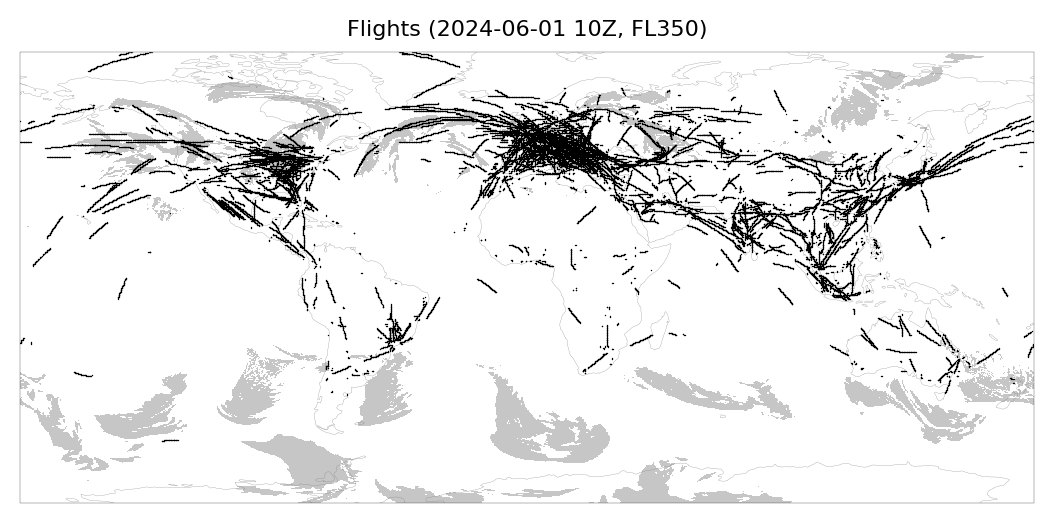

In [117]:
plt.figure(figsize=(6.5, 2.5), dpi=200, constrained_layout=True)
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.pcolormesh(forecast["longitude"], forecast["latitude"], forecast["pcr"].squeeze().T, vmax=3, cmap="Greys", shading="nearest")
ax.plot(adsb["longitude"], adsb["latitude"], "k.", mew=0, ms=1)
ax.coastlines(color="gray", lw=0.1)
plt.setp(ax.spines.values(), linewidth=0.1)
ax.set_title(f"Flights ({time.strftime('%Y-%m-%d %HZ')}, FL{flight_level})", fontsize=8)
ax.set_extent([-180, 180, -80, 80]);

# IAGOS data

2024 IAGOS data isn't available through the public API yet, so I'm using some provisional data that Roger processed himself. Again, worth considering whether there's a better place we could get this.

In [34]:
def get_iagos(time: datetime.datetime, flight_level: int) -> pd.DataFrame:
    """Get one hour of IAGOS data centered at target time and flight level.

    Parameters
    ----------
    time : datetime.datetime
        Target time

    flight_level : int
        Target flight level

    Returns
    -------
    pd.DataFrame
        Unprocessed IAGOS data

    """
    target = pd.Timestamp(time)
    start = target - pd.Timedelta(minutes=30)
    end = target + pd.Timedelta(minutes=30)

    gcs_path = "gs://contrails-301217-iagos-v2/Processed/2024/waypoints.pq"
    df = pd.read_parquet(gcs_path)

    df = df.sort_values(by=["flight_id", "time"])

    low = units.ft_to_m(flight_level * 100 - 500)
    high = units.ft_to_m(flight_level * 100 + 500)
    mask = (df["time"].between(start, end) & df["altitude_baro_m"].between(low, high)).values
    df = df[mask]

    return df

In [78]:
def process_iagos(time: datetime.datetime, flight_level: int) -> str:
    """Process IAGOS data for one hour and flight level.

    Parameters
    ----------
    time : datetime.datetime
        Target time

    flight_level : int
        Target flight level

    Returns
    -------
    str
        Path to processed IAGOS data saved as parquet file

    """
    df = get_iagos(time, flight_level)

    engine_efficiency = 0.3
    fuel = JetA()
    
    air_temperature = df["air_temperature"].values
    specific_humidity = 1e-6 * df["h2o_gas_ppmv"].values * constants.R_d / constants.R_v
    air_pressure = df["pressure"].values
    G = sac.slope_mixing_line(specific_humidity, air_pressure, engine_efficiency, fuel.ei_h2o, fuel.q_fuel)
    T_sat_liquid_ = sac.T_sat_liquid(G)
    rh_crit_sac = sac.rh_critical_sac(air_temperature, T_sat_liquid_, G)
    rh = thermo.rh(specific_humidity, air_temperature, air_pressure)
    rhi = thermo.rhi(specific_humidity, air_temperature, air_pressure)

    pcr = (rh > rh_crit_sac) & (rhi > 1.0)

    longitude = np.linspace(-180.0, 179.75, 1440)  # 0.25 degrees
    latitude = np.linspace(-80.0, 80.0, 641)  # 0.25 degrees
    longitude_bnds = np.linspace(-180.125, 179.875, 1441)
    latitude_bnds = np.linspace(-80.125, 80.125, 642)
    
    mask = df["longitude"] > longitude_bnds[-1]
    df.loc[mask, "longitude"] = df.loc[mask, "longitude"] - 360.0
    count, _, _, _ = binned_statistic_2d(
        df["longitude"].values,
        df["latitude"].values,
        pcr,
        bins=[longitude_bnds, latitude_bnds],
        statistic="sum"
    )

    longitude, latitude = np.meshgrid(longitude, latitude, indexing="ij")
    longitude = longitude.ravel()
    latitude = latitude.ravel()
    count = count.ravel()
    mask = count > 0

    df = pd.DataFrame({"longitude": longitude[mask], "latitude": latitude[mask]})
    sink = f"{int(time.timestamp())}_{flight_level}.iagos.pq"
    df.to_parquet(sink)
    return sink

In [79]:
sink = process_iagos(time, flight_level)
iagos = pd.read_parquet(sink)

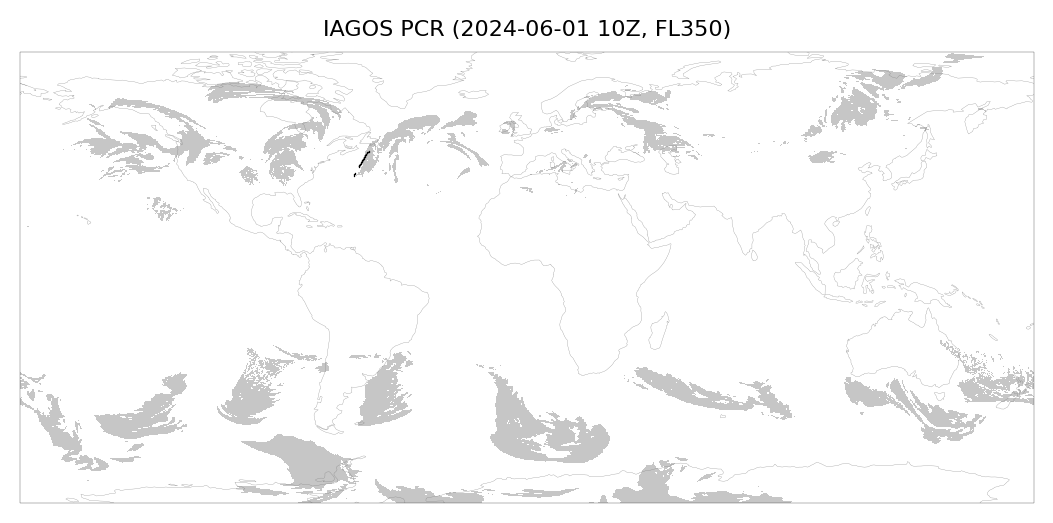

In [118]:
plt.figure(figsize=(6.5, 2.5), dpi=200, constrained_layout=True)
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.pcolormesh(forecast["longitude"], forecast["latitude"], forecast["pcr"].squeeze().T, vmax=3, cmap="Greys", shading="nearest")
ax.plot(iagos["longitude"], iagos["latitude"], "k.", mew=0, ms=1)
ax.coastlines(color="gray", lw=0.1)
plt.setp(ax.spines.values(), linewidth=0.1)
ax.set_title(f"IAGOS PCR ({time.strftime('%Y-%m-%d %HZ')}, FL{flight_level})", fontsize=8)
ax.set_extent([-180, 180, -80, 80]);

# Compute metrics (unbuffered)

In [119]:
adsb["forecast_pcr"] = adsb[["longitude", "latitude"]].apply(lambda x: forecast["pcr"].sel(longitude=x["longitude"], latitude=x["latitude"]).item(), axis="columns")

In [120]:
iagos["forecast_pcr"] = iagos[["longitude", "latitude"]].apply(lambda x: forecast["pcr"].sel(longitude=x["longitude"], latitude=x["latitude"]).item(), axis="columns")

In [121]:
flight_distance_fraction = adsb["flight_distance"].where(adsb["forecast_pcr"]).sum().item()/ adsb["flight_distance"].sum().item()
hit_rate = iagos["forecast_pcr"].sum() / len(iagos)

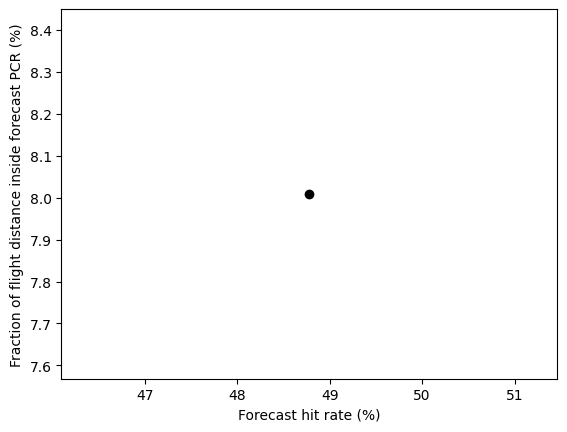

In [122]:
plt.plot(100 * hit_rate, 100 * flight_distance_fraction, "ko", label="Contrails.org")
plt.xlabel("Forecast hit rate (%)")
plt.ylabel("Fraction of flight distance inside forecast PCR (%)");